이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- numpy
- matplotlib

- 실습 기본 환경 설정

In [1]:
# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 7-1 똑똑한 어휘 사전, 임베딩

본 노트북은 본문 7-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 공개된 임베딩 데이터(GloVe 6B 100d)를 내려받아 어휘 사전과 임베딩 행렬로 불러오기
- 고유 번호 인덱싱으로 임베딩 벡터를 구하는 방법
- 가족 관계 단어 여덟 개의 임베딩 벡터를 PCA로 2차원에 시각화([그림 7-5])

## GloVe 임베딩 데이터 준비

- 본문에서 소개한 GloVe 공식 홈페이지(https://nlp.stanford.edu/projects/glove/)에서 `glove.6B.zip`을 내려받고, 그 안의 `glove.6B.100d.txt` 파일을 사용한다.
    - 학습 말뭉치: 60억 단어(6B token)
    - 어휘 사전: 40만 단어(400K vocab)
    - 임베딩 차원: 100(100d vectors)
- 다음 셀은 파일이 없으면 자동으로 내려받아 압축을 풀어 준비한다.
    - 압축 파일의 크기가 약 820MB이므로 디스크 여유 공간과 실행 시간을 미리 확인하자.

In [2]:
# 참고 - GloVe 임베딩 파일 준비
#   정해진 디렉터리에 파일이 없으면, 다운로드하고 압축을 풀어 준비
#   주의! 파일의 크기가 크므로(압축 파일 기준 약 820MB) 디스크가 충분한지 미리 확인해야 한다.

import urllib.request
import zipfile
from pathlib import Path

GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'

download_dir = Path('../../download')
glove_path = download_dir / 'glove.6B.100d.txt'
zip_path = download_dir / 'glove.6B.zip'


# urlretrieve()가 진행 상황을 알릴 때마다 호출하는 콜백 함수
def show_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    if total_size > 0:
        percent = min(downloaded / total_size * 100, 100)
        print(f'\r  내려받는 중 {percent:5.1f}% '
              f'({downloaded / 1024 / 1024:,.0f} / {total_size / 1024 / 1024:,.0f} MB)',
              end='')


if not glove_path.exists():
    download_dir.mkdir(parents=True, exist_ok=True)
    print(f'{glove_path.name} 파일이 없어 내려받는다.')
    print('압축 파일이 약 820MB로 크기 때문에 시간이 오래 걸린다.')

    # 내려받는 도중 중단되어도 다음 실행에서 손상된 파일을 쓰지 않도록
    # 임시 이름(.part)으로 받은 뒤 마지막에 이름을 변경
    part_path = zip_path.with_suffix('.zip.part')
    try:
        urllib.request.urlretrieve(GLOVE_URL, part_path, reporthook=show_progress)
        print()
        part_path.rename(zip_path)

        # 압축 파일에는 50, 100, 200, 300차원 파일이 모두 들어 있으므로 필요한 것만 꺼냄
        with zipfile.ZipFile(zip_path) as zf:
            zf.extract(glove_path.name, path=download_dir)
    finally:
        # 실패했든 성공했든 압축 파일 삭제
        part_path.unlink(missing_ok=True)
        zip_path.unlink(missing_ok=True)

    print(f'{glove_path.name} 준비 완료')

print(f'GloVe 파일 크기: {glove_path.stat().st_size / 1024 / 1024:.1f} MB')

GloVe 파일 크기: 331.0 MB


- 임베딩을 사용하려면 임베딩 행렬과 어휘 사전이 함께 있어야 한다.
    - `embedding`: 임베딩 행렬. 행 인덱스가 토큰의 고유 번호가 된다.
    - `vocab`: 토큰 문자열을 고유 번호로 옮기는 딕셔너리
- GloVe 파일은 한 줄에 '토큰 값1 값2 ... 값100' 형태로 저장되어 있어, 줄 단위로 읽어 두 자료구조를 함께 만들 수 있다.

In [3]:
# 참고 - GloVe 데이터를 (어휘 사전, 임베딩 행렬) 형태로 로드

#   embedding: 임베딩 행렬 - 행 인덱스 = 토큰 고유 번호
#   vocab: 토큰 -> 고유 번호 매핑 딕셔너리
import numpy as np

vocab = {}
embedding = []
with glove_path.open(encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        token = parts[0]
        # 딥러닝 모델은 보통 32비트 실수를 사용하므로 float32로 변환한 뒤 리스트로 저장
        vector = np.array(parts[1:], dtype=np.float32).tolist()
        vocab[token] = len(embedding)
        embedding.append(vector)

print(f'어휘 사전 크기: {len(vocab):,}')
print(f'임베딩 행렬 형태: {(len(embedding), len(embedding[0]))}')

어휘 사전 크기: 400,000
임베딩 행렬 형태: (400000, 100)


## 임베딩 벡터 확인

- 특정 토큰의 고유 번호로 임베딩 행렬을 인덱싱하면 임베딩 벡터를 구할 수 있다.
    - 어휘 사전의 크기가 커져도 행렬곱 없이 인덱스 하나를 읽는 비용에 그친다.

In [4]:
######################################################################################
# 코드 7-1 - 단어 boy의 임베딩 벡터 확인
######################################################################################

# embedding: 불러온 GloVe 임베딩(2차원 리스트), vocab: 어휘 사전(딕셔너리)
word = 'boy'                                        # 대상 단어

# 대상 단어의 고유 번호, 임베딩을 사용하려면 어휘 사전도 함께 구성해야 함
idx = vocab[word]

# 행렬곱 없이 고유 번호의 인덱싱만으로 임베딩 벡터를 구할 수 있음
embedding_vector = embedding[idx]
print(f'-- 단어 {word} --')
print(f'고유 번호: {idx}')                                  
print(f'임베딩 벡터 길이: {len(embedding_vector)}')         
print(f'임베딩 벡터의 첫 5개 요소: {embedding_vector[:5]}')

-- 단어 boy --
고유 번호: 1606
임베딩 벡터 길이: 100
임베딩 벡터의 첫 5개 요소: [0.8946099877357483, 0.3775799870491028, 0.4206700026988983, -0.5133399963378906, -0.2829799950122833]


- 단어 `boy`의 고유 번호는 1606이고, 임베딩 벡터의 길이는 임베딩 차원과 같은 100이다.

## PCA로 임베딩 벡터 시각화([그림 7-5])

- 임베딩 벡터를 구성하는 숫자를 들여다봐도 그 안의 의미는 알 수 없다.
    - 여러 벡터를 하나의 좌표 공간에 그려 보면 도움이 되지만, 100차원 공간은 시각화할 수 없다.
- 차원 축소 기법으로 정보를 최대한 보존하면서 2차원으로 압축하면 평면에 그릴 수 있다.
    - 대표적인 알고리즘이 주성분 분석(PCA)이다.

### 참고 - PCA로 100차원 벡터를 2차원으로 압축하기

- **그림자에 빗대면 이해하기 쉽다.** 3차원 물체에 빛을 비추면 벽에 2차원 그림자가 생긴다. 어느 방향에서 비추는지에 따라 그림자가 물체의 모양을 잘 담기도 하고, 뭉개지기도 한다.
    - PCA는 '데이터가 가장 많이 퍼진 방향'으로 빛을 비추는 방법을 찾는다. 이 방향을 주성분이라고 부른다.
- 계산 과정은 두 단계다.
    1. 데이터의 평균을 빼서 원점을 중심으로 옮긴다(중심화).
    2. 데이터가 가장 넓게 퍼진 첫 번째 방향과, 그에 수직이면서 다음으로 넓게 퍼진 두 번째 방향을 찾아 그 두 방향으로 투영한다.
- 두 번째 단계는 특잇값 분해(SVD)로 구할 수 있어, 넘파이의 `np.linalg.svd()`를 사용한다.

In [5]:
# 참고 - PCA로 임베딩 벡터를 2차원으로 투영, 압축

family_words = [
    'father', 'mother', 'son', 'daughter',
    'uncle', 'aunt', 'nephew', 'niece',
]

# 각 단어의 임베딩 벡터 추출
vectors = np.array(
    [embedding[vocab[w]] for w in family_words],
)                                                             # (8, 100)

# 평균을 빼서 중심화한 뒤 SVD 기반 PCA 로 처음 두 주성분에 투영
mean = vectors.mean(axis=0)
centered = vectors - mean
# numpy의 SVD를 사용해 PCA 수행
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
projection = centered @ Vt.T[:, :2]                           # (8, 2)

print('--- PCA 투영 결과 ---')
for w, p in zip(family_words, projection):
    print(f'{w:8s}: ({p[0]:+.3f}, {p[1]:+.3f})')

--- PCA 투영 결과 ---
father  : (-1.378, -1.194)
mother  : (+1.263, -1.952)
son     : (-2.118, -0.550)
daughter: (+0.552, -1.418)
uncle   : (-0.662, +1.206)
aunt    : (+2.495, +0.877)
nephew  : (-1.268, +1.819)
niece   : (+1.117, +1.212)


- 투영 결과를 점으로 표시하고, 관계가 있는 단어 사이를 보조선으로 연결해 본문 [그림 7-5]를 재현한다.

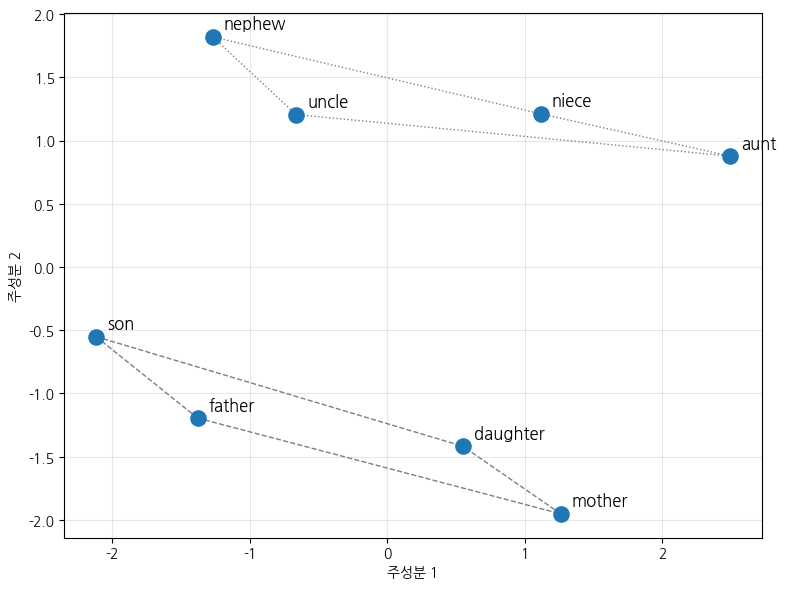

In [6]:
# 참고 - PCA 투영 결과를 점으로 나타내고, 관계 단어 사이의 보조 연결선 표시 시각화([그림 7-5])
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# 단어 점 표시
ax.scatter(
    projection[:, 0], projection[:, 1], s=120, c='tab:blue', zorder=3,
)
# 단어 라벨
for w, (x, y) in zip(family_words, projection):
    ax.annotate(
        w, (x, y),
        textcoords='offset points', xytext=(8, 6),
        fontsize=12, zorder=4,
    )

# 직계 가족 사각형 (father-mother-son-daughter)
direct = [
    ('father', 'mother'),    # 부모 사이 (성별 관계)
    ('son', 'daughter'),     # 자식 사이 (성별 관계)
    ('father', 'son'),       # 직계 남자 (부모-자식)
    ('mother', 'daughter'),  # 직계 여자 (부모-자식)
]
for a, b in direct:
    ia, ib = family_words.index(a), family_words.index(b)
    ax.plot(
        [projection[ia, 0], projection[ib, 0]],
        [projection[ia, 1], projection[ib, 1]],
        color='tab:gray', linestyle='--', linewidth=1, zorder=2,
    )

# 삼촌 가족 사각형 (uncle-aunt-nephew-niece)
uncle = [
    ('uncle', 'aunt'),
    ('nephew', 'niece'),
    ('uncle', 'nephew'),
    ('aunt', 'niece'),
]
for a, b in uncle:
    ia, ib = family_words.index(a), family_words.index(b)
    ax.plot(
        [projection[ia, 0], projection[ib, 0]],
        [projection[ia, 1], projection[ib, 1]],
        color='tab:gray', linestyle=':', linewidth=1, zorder=2,
    )

#ax.set_title('가족 관계 단어들의 GloVe 임베딩 PCA 시각화')
ax.set_xlabel('주성분 1')
ax.set_ylabel('주성분 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
viz._finalize(fig)
plt.show()

- 본문 [그림 7-5]처럼 직계 가족과 삼촌 가족이 두 군집으로 모이고, 성별과 세대 관계가 평행하게 나타나는 경향을 볼 수 있다.
    - PCA는 분산이 큰 두 방향에 투영하는 선형 기법이므로 본문 그림과 정확히 같은 좌표로 일치하지는 않는다.
    - 비선형 기법(t-SNE, UMAP)을 사용하면 군집 구조가 더 또렷해진다.

## 정리

- 임베딩은 토큰을 고유 번호로 인덱싱해 임베딩 벡터를 얻는 구조여서, 어휘 사전이 커져도 연산 비용이 늘지 않는다.
- GloVe는 단어가 같은 문장에 함께 등장하는 빈도만 학습했지만, 그 속에 녹아 있는 관계 맥락을 임베딩 벡터에 담아낸다.
- 고차원 임베딩 벡터는 PCA 등의 차원 축소 기법으로 2차원에 투영해 관계를 눈으로 확인할 수 있다.